No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Starting Training...
Epoch [10/50], Loss: 0.4954, Accuracy: 1.0000
Epoch [20/50], Loss: 0.4540, Accuracy: 1.0000
Epoch [30/50], Loss: 0.4376, Accuracy: 1.0000
Epoch [40/50], Loss: 0.4359, Accuracy: 1.0000
Epoch [50/50], Loss: 0.4338, Accuracy: 1.0000
Training Complete!


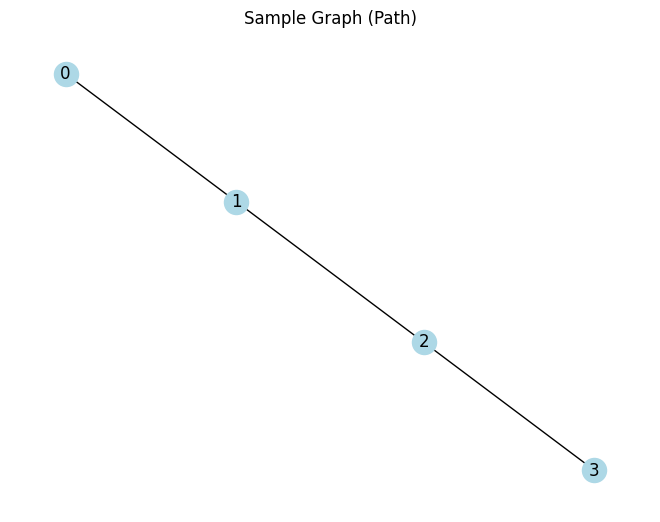


Quantum Circuit Structure:
     ┌──────────┐                                 ┌──────────┐           »
q_0: ┤ Ry(x[0]) ├─■──────────■──────────■─────────┤ Ry(w[0]) ├───────────»
     ├──────────┤ │ZZ(x[4])  │          │         └──────────┘           »
q_1: ┤ Ry(x[1]) ├─■──────────┼──────────┼──────────■───────────■─────────»
     ├──────────┤            │ZZ(x[5])  │          │ZZ(x[7])   │         »
q_2: ┤ Ry(x[2]) ├────────────■──────────┼──────────■───────────┼─────────»
     ├──────────┤                       │ZZ(x[6])              │ZZ(x[8]) »
q_3: ┤ Ry(x[3]) ├───────────────────────■──────────────────────■─────────»
     └──────────┘                                                        »
«                             ┌──────────┐                        
«q_0: ─────────────────■──────┤ Ry(w[4]) ├────────────────────────
«     ┌──────────┐   ┌─┴─┐    └──────────┘┌──────────┐            
«q_1: ┤ Ry(w[1]) ├───┤ X ├─────────■──────┤ Ry(w[5]) ├────────────
«     └──────────┘┌──┴───┴───

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# PyTorch for training loop
import torch
import torch.nn as nn
import torch.optim as optim

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# ==========================================
# 1. Dataset Generation
# ==========================================
NUM_NODES = 4
NUM_GRAPHS = 100

def generate_graph_dataset(num_graphs, num_nodes):
    """Generates a dataset of Cycle graphs (Label 1) and Path graphs (Label 0)."""
    graphs = []
    labels = []
    
    for i in range(num_graphs):
        if i % 2 == 0:
            G = nx.path_graph(num_nodes) # Path graph
            labels.append(0)
        else:
            G = nx.cycle_graph(num_nodes) # Cycle graph
            labels.append(1)
        graphs.append(G)
        
    return graphs, labels

graphs, labels = generate_graph_dataset(NUM_GRAPHS, NUM_NODES)

# ==========================================
# 2. Feature Extraction
# ==========================================
def graph_to_features(G):
    """Extracts node degrees and adjacency matrix features for a graph."""
    num_nodes = len(G.nodes)
    
    # Node features: Degree of the node (normalized)
    node_features = np.array([G.degree(n) / 2.0 for n in range(num_nodes)])
    
    # Edge features: Flattened upper triangle of adjacency matrix
    adj_matrix = nx.to_numpy_array(G)
    edge_features = []
    for i in range(num_nodes):
        for j in range(i+1, num_nodes):
            # Scale adjacency to pi for RZZ gates
            edge_features.append(adj_matrix[i, j] * np.pi) 
            
    return np.concatenate([node_features, edge_features])

# Prepare X and y for PyTorch
X = np.array([graph_to_features(G) for G in graphs])
y = np.array(labels)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# ==========================================
# 3. Quantum Graph Neural Network Circuit
# ==========================================
def create_qgnn_circuit(num_nodes):
    """Creates the QGNN quantum circuit."""
    num_node_features = num_nodes
    num_edge_features = num_nodes * (num_nodes - 1) // 2
    total_features = num_node_features + num_edge_features
    
    # Input parameters (Graph Features)
    input_params = ParameterVector("x", total_features)
    # Trainable parameters (Ansatz)
    weight_params = ParameterVector("w", num_nodes * 2) # 2 layers of rotations
    
    qc = QuantumCircuit(num_nodes)
    
    # --- ENCODING LAYER ---
    # 1. Encode Node Features (Single qubit rotations)
    for i in range(num_nodes):
        qc.ry(input_params[i], i)
        
    # 2. Encode Edges / Adjacency (Two-qubit entanglements representing message passing)
    edge_idx = num_nodes
    for i in range(num_nodes):
        for j in range(i+1, num_nodes):
            # RZZ gate entangles qubits based on graph connectivity
            qc.rzz(input_params[edge_idx], i, j)
            edge_idx += 1
            
    # --- TRAINABLE ANSATZ ---
    # Layer 1: Parameterized rotations
    for i in range(num_nodes):
        qc.ry(weight_params[i], i)
        
    # Entanglement between neighbors
    for i in range(num_nodes - 1):
        qc.cx(i, i+1)
        
    # Layer 2: Parameterized rotations
    for i in range(num_nodes):
        qc.ry(weight_params[num_nodes + i], i)

    return qc, input_params, weight_params

qc, input_params, weight_params = create_qgnn_circuit(NUM_NODES)

# Define Observables (Measurements)
# We measure the Pauli Z expectation on the first two qubits to get 2 outputs (for 2 classes)
observables = [
    SparsePauliOp.from_list([("Z" + "I" * (NUM_NODES - 1), 1.0)]),  # ZIII
    SparsePauliOp.from_list([("IZ" + "I" * (NUM_NODES - 2), 1.0)])  # IZII
]

# ==========================================
# 4. Qiskit-PyTorch Integration
# ==========================================
# Use Qiskit's statevector estimator for fast local simulation
estimator = StatevectorEstimator()

# Create the EstimatorQNN
qnn = EstimatorQNN(
    estimator=estimator,
    circuit=qc,
    observables=observables,
    input_params=input_params,
    weight_params=weight_params
)

# Wrap in TorchConnector to use as a PyTorch layer
quantum_layer = TorchConnector(qnn)

# Build the Hybrid Model
class QGNNClassifier(nn.Module):
    def __init__(self, quantum_layer):
        super().__init__()
        self.quantum = quantum_layer
        # Optional: classical post-processing
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        # Pass data through quantum layer
        quantum_out = self.quantum(x)
        # Apply softmax to get probabilities
        return self.softmax(quantum_out)

model = QGNNClassifier(quantum_layer)

# ==========================================
# 5. Training Loop
# ==========================================
optimizer = optim.Adam(model.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()

epochs = 50
batch_size = 10

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass (Full batch for simplicity)
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    # Calculate Accuracy
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == y_tensor).sum().item()
    accuracy = correct / y_tensor.size(0)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}")

print("Training Complete!")

# ==========================================
# 6. Visualize one of the Graphs and the Circuit
# ==========================================
# Draw the first graph (Label 0: Path)
nx.draw(graphs[0], with_labels=True, node_color='lightblue')
plt.title("Sample Graph (Path)")
plt.show()

# Print the Quantum Circuit
print("\nQuantum Circuit Structure:")
print(qc.draw(output='text'))

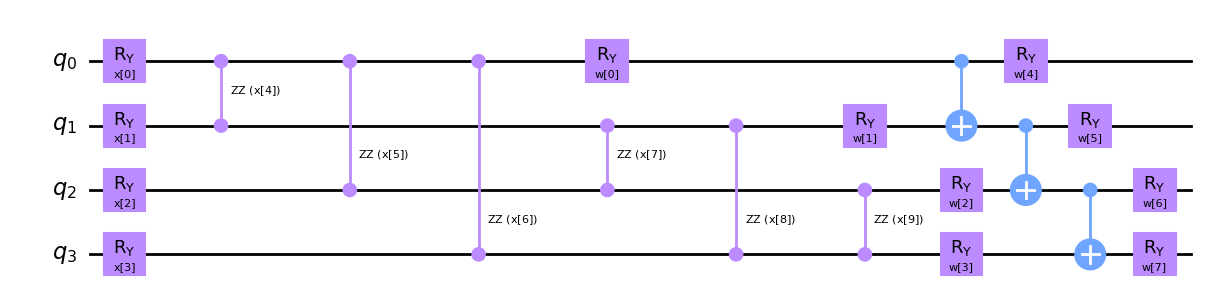

In [2]:
qc.draw(output="mpl", style="clifford")

Simple Quantum Graph Neural Network (QGNN) in Qiskit
======================================================

Task: binary graph classification.
  - Class +1: "cycle" graphs   (4 nodes, edges 0-1, 1-2, 2-3, 3-0)
  - Class -1: "path"  graphs   (4 nodes, edges 0-1, 1-2, 2-3)

Each graph = one qubit per node. Edges become RZZ entangling gates
(shared angle per layer -> weight sharing, same idea as classical GNNs).
A layer of single-qubit Ry rotations follows each entangling layer
(the "update" step). We stack L such layers, then read out the
graph-level prediction as the POOLED average of <Z_i> over all qubits.

Training uses the exact parameter-shift rule (shift = pi/2), which is
exact for gates of the form exp(-i*theta*G) with eigenvalues +-1/2 (Ry, RZZ
both qualify after a factor-of-2 convention below). We use Qiskit's
StatevectorEstimator for noise-free gradient descent so the mechanics
are crystal clear; swapping in a shot-based EstimatorV2 (or a real
IBM backend) at the end only requires changing one line.

## Dataset 

In [9]:
import numpy as np
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
import matplotlib.pylab as plt

In [ ]:
rng = np.random.default_rng(42)

# ----------------------------------------------------------------------
# 1. Build the toy dataset: several cycle graphs and several path graphs
#    on 4 nodes, each with a different qubit-labeling (permutation) and
#    a bit of feature noise, so the circuits are not all identical.
# ----------------------------------------------------------------------
N_QUBITS = 4
CYCLE_EDGES = [(0, 1), (1, 2), (2, 3), (3, 0)]
PATH_EDGES = [(0, 1), (1, 2), (2, 3)]


def make_dataset(n_per_class=6):
    # NOTE: we keep a FIXED qubit labeling per class (no random permutation).
    # Node identity must stay consistent across examples, since the
    # per-node update parameters phi[l, q] are tied to physical qubit
    # index q. Randomly permuting node labels between examples would ask
    # the same phi[l, q] to mean different things on different graphs,
    # which the model has no way to learn from. Augmentation instead
    # comes from small noise added to the node features.
    
    data = []
    for _ in range(n_per_class):
        feats = 0.4 * np.pi + 0.15 * rng.normal(size=N_QUBITS)  # node features
        data.append((CYCLE_EDGES, feats, +1))
    for _ in range(n_per_class):
        feats = 0.4 * np.pi + 0.15 * rng.normal(size=N_QUBITS)
        data.append((PATH_EDGES, feats, -1))
    rng.shuffle(data)
    return data


dataset = make_dataset(n_per_class=6)
n_train = len(dataset)

print(dataset[0])
print(n_train)


([(0, 1), (1, 2), (2, 3), (3, 0)], array([1.31194968, 1.11280467, 1.38840461, 1.24914817]), 1)
12


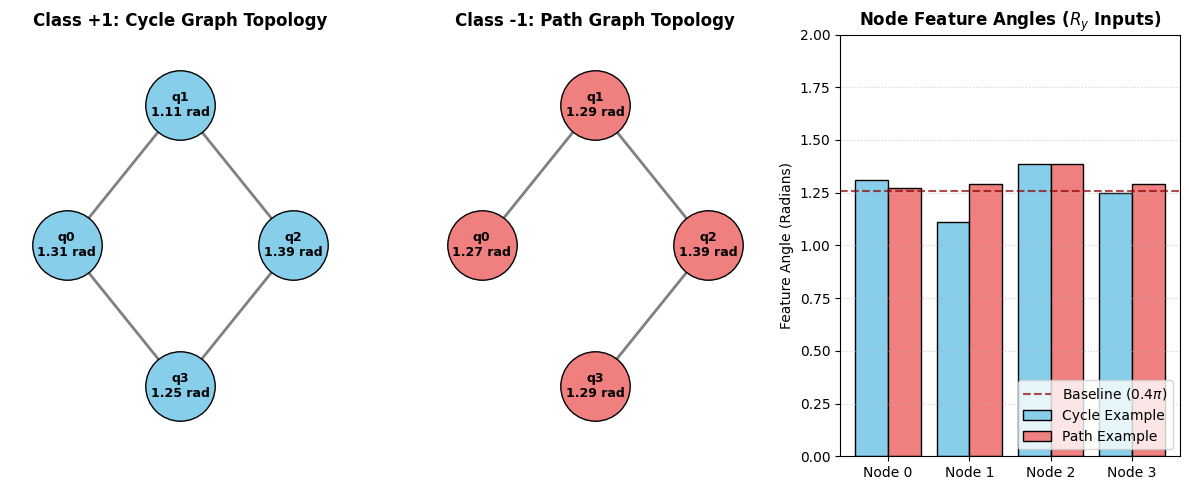

In [15]:
# ---------------------------------------------------------
# Visualization dataset
# ---------------------------------------------------------
# Extract one Cycle graph (Class +1) and one Path graph (Class -1)
cycle_example = [g for g in dataset if g[2] == 1][0]
path_example = [g for g in dataset if g[2] == -1][0]

fig = plt.figure(figsize=(12, 5))

# Define fixed positions for a nice diamond/square layout for 4 nodes
pos = {0: (0, 1), 1: (1, 2), 2: (2, 1), 3: (1, 0)}

# --- Plot 1: Cycle Graph Structure ---
ax1 = fig.add_subplot(131)
ax1.set_title("Class +1: Cycle Graph Topology", fontsize=12, fontweight="bold")
# Draw nodes manually for clean control without external networkx dependencies
for node, (x, y) in pos.items():
    ax1.scatter(x, y, s=2500, color="skyblue", edgecolors="black", zorder=3)
    ax1.text(
        x,
        y,
        f"q{node}\n{cycle_example[1][node]:.2f} rad",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
    )
for edge in cycle_example[0]:
    p1, p2 = pos[edge[0]], pos[edge[1]]
    ax1.plot([p1[0], p2[0]], [p1[1], p2[1]], color="gray", linewidth=2, zorder=2)
ax1.set_xlim(-0.5, 2.5)
ax1.set_ylim(-0.5, 2.5)
ax1.axis("off")

# --- Plot 2: Path Graph Structure ---
ax2 = fig.add_subplot(132)
ax2.set_title("Class -1: Path Graph Topology", fontsize=12, fontweight="bold")
for node, (x, y) in pos.items():
    ax2.scatter(x, y, s=2500, color="lightcoral", edgecolors="black", zorder=3)
    ax2.text(
        x,
        y,
        f"q{node}\n{path_example[1][node]:.2f} rad",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
    )
for edge in path_example[0]:
    p1, p2 = pos[edge[0]], pos[edge[1]]
    ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], color="gray", linewidth=2, zorder=2)
ax2.set_xlim(-0.5, 2.5)
ax2.set_ylim(-0.5, 2.5)
ax2.axis("off")

# --- Plot 3: Feature Distribution Profiling ---
ax3 = fig.add_subplot(133)
ax3.set_title("Node Feature Angles ($R_y$ Inputs)", fontsize=12, fontweight="bold")
x_indices = np.arange(N_QUBITS)

ax3.bar(
    x_indices - 0.2,
    cycle_example[1],
    width=0.4,
    label="Cycle Example",
    color="skyblue",
    edgecolor="black",
)
ax3.bar(
    x_indices + 0.2,
    path_example[1],
    width=0.4,
    label="Path Example",
    color="lightcoral",
    edgecolor="black",
)

ax3.axhline(
    0.4 * np.pi,
    color="darkred",
    linestyle="--",
    alpha=0.7,
    label="Baseline ($0.4\pi$)",
)
ax3.set_xticks(x_indices)
ax3.set_xticklabels([f"Node {i}" for i in range(N_QUBITS)])
ax3.set_ylabel("Feature Angle (Radians)")
ax3.set_ylim(0, 2.0)
ax3.legend(loc="lower right")
ax3.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## QGNN circuit

In [ ]:
# ----------------------------------------------------------------------
# 2. The QGNN ansatz: one QGCL (Quantum Graph Convolutional Layer) per
#    layer = [shared RZZ over every edge] -> [per-qubit Ry update].
#    Parameters: theta_l (1 scalar per layer, shared across ALL edges)
#                phi_l   (N_QUBITS angles per layer, one per node)
# ----------------------------------------------------------------------

N_LAYERS = 2

def build_qgnn_circuit(edges, feats, theta, phi):
    """theta: shape (N_LAYERS,)   phi: shape (N_LAYERS, N_QUBITS)"""
    qc = QuantumCircuit(N_QUBITS)

    # --- encode node features with angle encoding ---
    for q in range(N_QUBITS):
        qc.ry(float(feats[q]), q)

    # --- L quantum graph conv layers ---
    for l in range(N_LAYERS):
        # message passing: same theta for every edge (weight sharing)
        for (i, j) in edges:
            qc.rzz(float(theta[l]), i, j)
        
        # per-node update
        for q in range(N_QUBITS):
            qc.ry(float(phi[l, q]), q)
            
        qc.barrier()

    return qc

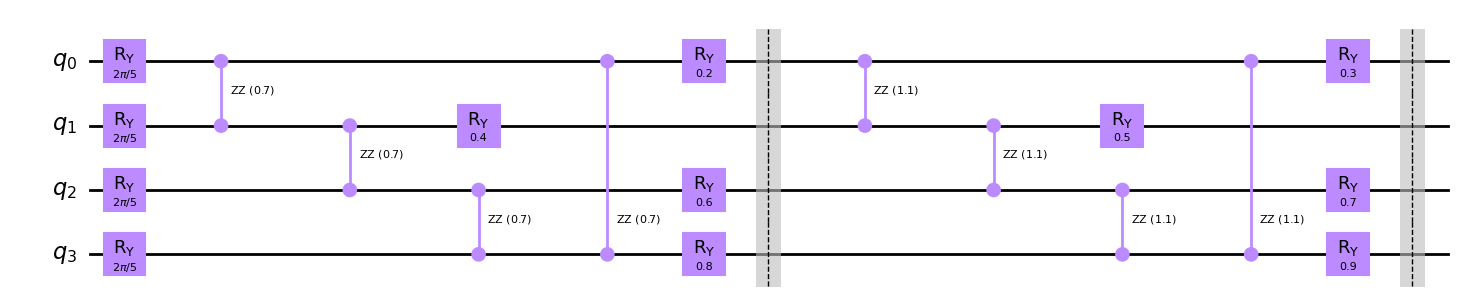

In [27]:
# Example parameters just for visualization
theta_example = np.array([0.7, 1.1])
phi_example = np.array([
    [0.2, 0.4, 0.6, 0.8],
    [0.3, 0.5, 0.7, 0.9]
])

# Example node features
feats_example = np.array([0.4*np.pi, 0.4*np.pi, 0.4*np.pi, 0.4*np.pi])

# Build cycle and path QGNN circuits
qc_cycle = build_qgnn_circuit(CYCLE_EDGES,feats_example,theta_example,phi_example)

qc_path = build_qgnn_circuit(PATH_EDGES,feats_example,theta_example,phi_example)

# Draw cycle circuit
qc_cycle.draw(output="mpl", style="clifford")

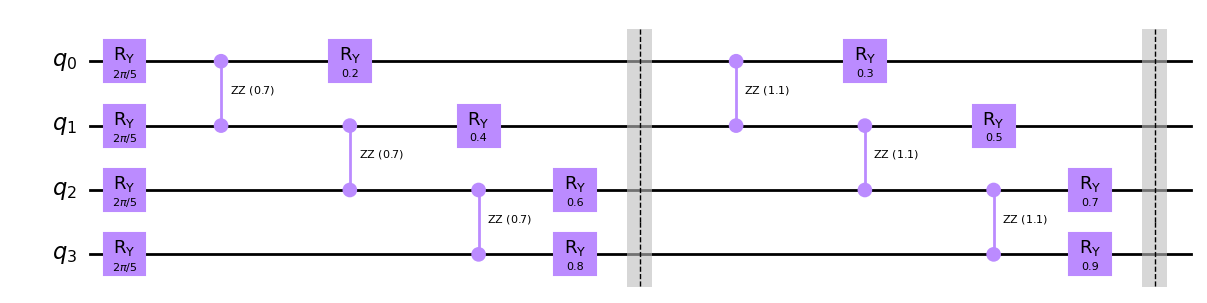

In [28]:
qc_path.draw(output="mpl", style="clifford")

## Loss and training computation

In [ ]:
# QGNN prediction (expectation value) using estimator
def graph_prediction(edges, feats, theta, phi, estimator):
    """Pooled graph-level output: average <Z_i> over all qubits."""
    qc = build_qgnn_circuit(edges, feats, theta, phi)
    obs = [SparsePauliOp("I" * k + "Z" + "I" * (N_QUBITS - 1 - k)) for k in range(N_QUBITS)]
    job = estimator.run([(qc, o) for o in obs])
    result = job.result()
    z_vals = [r.data.evs for r in result]
    return float(np.mean(z_vals))

print([SparsePauliOp("I" * k + "Z" + "I" * (N_QUBITS - 1 - k)) for k in range(N_QUBITS)])

[SparsePauliOp(['ZIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IZII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIZI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIZ'],
              coeffs=[1.+0.j])]


In [30]:
# ----------------------------------------------------------------------
# 3. Loss function over the whole dataset (mean squared error, labels +-1)
# ----------------------------------------------------------------------
def dataset_loss(theta, phi, estimator):
    total = 0.0
    for edges, feats, label in dataset:
        yhat = graph_prediction(edges, feats, theta, phi, estimator)
        total += (yhat - label) ** 2
    return total / n_train

In [ ]:
# ----------------------------------------------------------------------
# 4. Parameter-shift gradient descent
# ----------------------------------------------------------------------
def flatten(theta, phi):
    return np.concatenate([theta, phi.ravel()])

def unflatten(vec):
    theta = vec[:N_LAYERS]
    phi = vec[N_LAYERS:].reshape(N_LAYERS, N_QUBITS)
    return theta, phi

def parameter_shift_grad(vec, estimator, shift=np.pi / 2):
    grad = np.zeros_like(vec)
    for k in range(len(vec)):
        # plus loss 
        vec_plus = vec.copy();
        vec_plus[k] += shift
        # minus loss
        vec_minus = vec.copy();
        vec_minus[k] -= shift
        theta_p, phi_p = unflatten(vec_plus)
        theta_m, phi_m = unflatten(vec_minus)
        loss_plus = dataset_loss(theta_p, phi_p, estimator)
        loss_minus = dataset_loss(theta_m, phi_m, estimator)
        grad[k] = (loss_plus - loss_minus) / 2.0
    return grad

In [ ]:
def train(n_steps=60, lr=0.25):
    estimator = StatevectorEstimator()

    theta = rng.uniform(0, np.pi / 2, size=N_LAYERS)
    phi = rng.uniform(0, np.pi / 2, size=(N_LAYERS, N_QUBITS))
    vec = flatten(theta, phi)

    # Adam optimizer state (plain gradient descent oscillates on this
    # landscape; Adam's per-parameter adaptive step size converges much
    # more reliably for a handful of parameter-shift gradients)
    m = np.zeros_like(vec); v = np.zeros_like(vec)
    b1, b2, eps = 0.9, 0.999, 1e-8

    history = []
    for step in range(1, n_steps + 1):
        theta, phi = unflatten(vec)
        loss = dataset_loss(theta, phi, estimator)
        history.append(loss)
        grad = parameter_shift_grad(vec, estimator)
        # Adaptive Moment Estimation 
        m = b1 * m + (1 - b1) * grad
        v = b2 * v + (1 - b2) * grad**2
        m_hat = m / (1 - b1**step)
        v_hat = v / (1 - b2**step)
        vec = vec - lr * m_hat / (np.sqrt(v_hat) + eps)

        if step % 10 == 0 or step == 1 or step == n_steps:
            print(f"step {step:2d}   loss = {loss:.4f}")

    return unflatten(vec), history, estimator

In [34]:
def evaluate(theta, phi, estimator):
    correct = 0
    for edges, feats, label in dataset:
        yhat = graph_prediction(edges, feats, theta, phi, estimator)
        pred = 1 if yhat > 0 else -1
        correct += int(pred == label)
    return correct / n_train

## Final result

In [ ]:
if __name__ == "__main__":
    print(f"Dataset: {n_train} graphs "
          f"({sum(1 for *_, l in dataset if l == 1)} cycles, "
          f"{sum(1 for *_, l in dataset if l == -1)} paths)\n")

    (theta_final, phi_final), history, estimator = train(n_steps=60, lr=0.25)

    acc = evaluate(theta_final, phi_final, estimator)
    print(f"\nFinal training accuracy: {acc*100:.1f}%")
    print(f"Final theta (edge coupling per layer): {theta_final}")
    print(f"Final phi   (per-node update per layer):\n{phi_final}")


Dataset: 12 graphs (6 cycles, 6 paths)

step  1   loss = 0.8769
step 10   loss = 1.0906
step 20   loss = 0.3578
step 30   loss = 0.3481
step 40   loss = 0.3005
step 50   loss = 0.2827
step 60   loss = 0.2778

Final training accuracy: 100.0%
Final theta (edge coupling per layer): [-2.49477008 -0.67640572]
Final phi   (per-node update per layer):
[[-0.08912872 -0.06732324 -0.03381527 -0.16826174]
 [-1.45826562 -1.13260005  2.0017521  -1.32047943]]
